In [ ]:
import pandas as pd
import sqlite3
import json
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

from tqdm.auto import tqdm
tqdm.pandas()

db_path = r"C:\sqlite3\chess.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()
df = pd.read_sql_query("SELECT * FROM clock", conn)
conn.close()

In [3]:
df.head()

,uid,seconds
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180..."


In [8]:
# data\input\100wuid.csv
df.to_csv(r'..\..\data\input\clock_info.csv', index=False)

In [19]:
df['seconds'].values
#str形式的，要转成真list

array(['[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178.6, 176.5, 178.7, 176.5, 178.0, 176.1, 177.3, 174.2, 177.3, 174.2, 176.4, 174.4, 175.3, 173.6, 175.0, 172.6, 174.1, 172.2, 173.6, 170.6]',
       '[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177.7, 178.0, 177.6, 176.6, 177.9, 175.9, 177.1, 173.2, 176.8, 164.7, 173.4, 164.9, 170.2, 152.3, 167.5, 148.0, 165.0, 147.6, 158.4, 146.3, 157.5]',
       '[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178.1, 177.1, 179.0, 173.1, 175.2, 172.0, 174.9, 171.9, 175.1, 172.4, 172.3, 172.1, 171.1, 171.1, 170.9, 167.7, 171.8, 165.6, 169.5, 165.1, 153.2, 156.2, 152.9, 155.9, 148.9, 151.7, 149.8, 149.7, 137.4, 142.1, 135.3, 131.7, 132.7]',
       ...,
       '[180.9, 178.9, 180.5, 178.3, 179.3, 178.6, 179.3, 178.1, 178.5, 177.0, 176.5, 170.9, 176.6, 170.1, 170.5, 167.5, 167.0, 164.9, 164.7, 153.8, 164.6, 154.0, 165.5, 153.2, 155.5, 151.1, 156.4, 150.9, 154.7, 141.0, 153.9, 126.5, 150.8, 112.0, 144.6, 109.6, 134.4, 108.0, 128.9, 103.0, 127.0, 94.8, 124.6, 88

In [23]:
df['second_list'] = df['seconds'].progress_apply(ast.literal_eval)
df.head()

  0%|          | 0/1017708 [00:00<?, ?it/s]

,uid,seconds,second_list
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180..."


split "seconds" into white/black 's perspective

In [24]:
def split_white_black(sec_list):
    white = sec_list[::2]
    black = sec_list[1::2]
    return white, black
# sec_list = [1,2,3,4,5,6,7,8]
# print(split_white_black(sec_list))
df[['white_sec', 'black_sec']] = (df['second_list'].progress_apply(lambda x: pd.Series(split_white_black(x))))
# df = df.drop(columns=['white_sec', 'black_sec', 'seconds_list'])

  0%|          | 0/1017708 [00:00<?, ?it/s]

In [25]:
df.head()

,uid,seconds,second_list,white_sec,black_sec
0,1,"[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 178.3, 179.1, 178.0, 179.4, 177.2, 178...","[180.1, 179.1, 179.4, 178.6, 178.7, 178.0, 177...","[178.3, 178.0, 177.2, 176.5, 176.5, 176.1, 174..."
1,2,"[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 179.1, 178.5, 178.5, 178.3, 178.2, 177...","[179.4, 178.5, 178.3, 177.7, 177.6, 177.9, 177...","[179.1, 178.5, 178.2, 178.0, 176.6, 175.9, 173..."
2,3,"[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 178.3, 180.4, 177.0, 180.5, 177.1, 178...","[179.9, 180.4, 180.5, 178.1, 179.0, 175.2, 174...","[178.3, 177.0, 177.1, 177.1, 173.1, 172.0, 171..."
3,4,"[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.3, 179.2, 174.2, 173.9, 174.0, 173...","[179.4, 179.2, 173.9, 173.9, 167.6, 166.7, 161...","[179.3, 174.2, 174.0, 173.9, 171.7, 171.4, 170..."
4,5,"[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 177.1, 180.9, 173.7, 181.0, 172.2, 180...","[180.9, 180.9, 181.0, 180.2, 179.9, 180.8, 181...","[177.1, 173.7, 172.2, 170.7, 170.0, 170.1, 165..."


"second_list" distribution

In [26]:
all_seconds = []
for idx, row in tqdm(df.iterrows(), total=len(df), desc="Collecting all secondsa"):
    sec_list = row['second_list']
    all_seconds.extend(sec_list)
print(f"total length:{len(all_seconds)}")
print(f"seconds' range:{min(all_seconds)}~{max(all_seconds)}")

total length:88912060
seconds' range:0.1~638.8


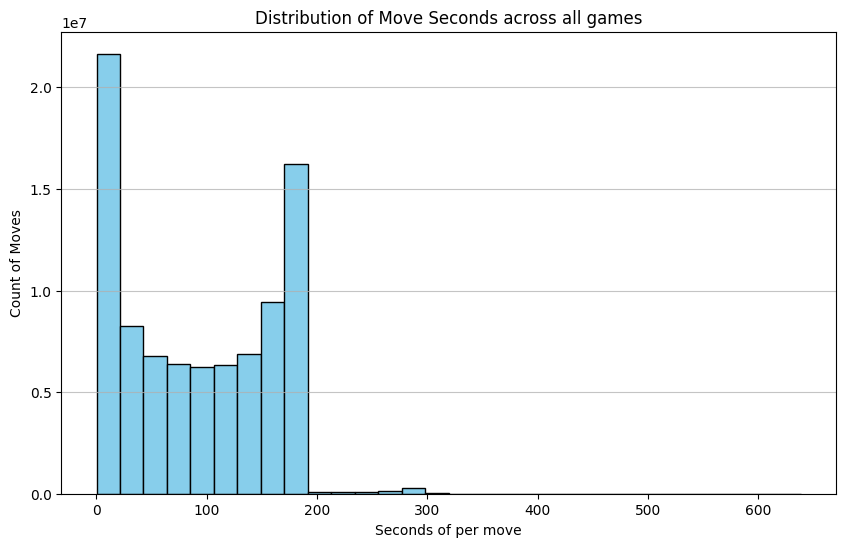

In [27]:
all_seconds_serise = pd.Series(all_seconds)
plt.figure(figsize=(10, 6))
plt.hist(all_seconds, bins=30, color="skyblue", edgecolor = 'black')
plt.title("Distribution of Move Seconds across all games")
plt.xlabel("Seconds of per move")
plt.ylabel("Count of Moves")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
os.makedirs(r"..\..\data\input", exist_ok=True)
df.to_csv(r'..\..\data\input\clock_info.csv', index=False)